In [1]:
pip install librosa


   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 439.2 kB/s eta 0:00:02
   -------------------- ------------------- 0.5/1.0 MB 439.2 kB/s eta 0:00:02
   -------------------- ------------------- 0.5/1.0 MB 439.2 kB/s eta 0:00:02
   ------------------------------ --------- 0.8/1.0 MB 461.1 kB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 492.1 kB/s  0:00:02

   ---- ----------------------------------- 1/9 [soxr]
   -------- ------------------------------- 2/9 [audioop-lts]
   ------------- -------------------------- 3/9 [standard-sunau]
   ------------

In [1]:
import pandas as pd
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import glob

In [2]:
#Loading the data
file_path = r"C:\Users\Shyam\Downloads\audio dataset\Raw Audio\car_crash\3-0.wav"
signal, sr = librosa.load(file_path, sr=22050)

print(f"Audio shape: {signal.shape}")
display(Audio(signal, rate=sr))

Audio shape: (64210,)


In [25]:
#Pre-processing - Normalization
signal = librosa.util.normalize(signal)

In [26]:
#Trimming the audio to remove the zero effect
signal, idx = librosa.effects.trim(signal, top_db=30)

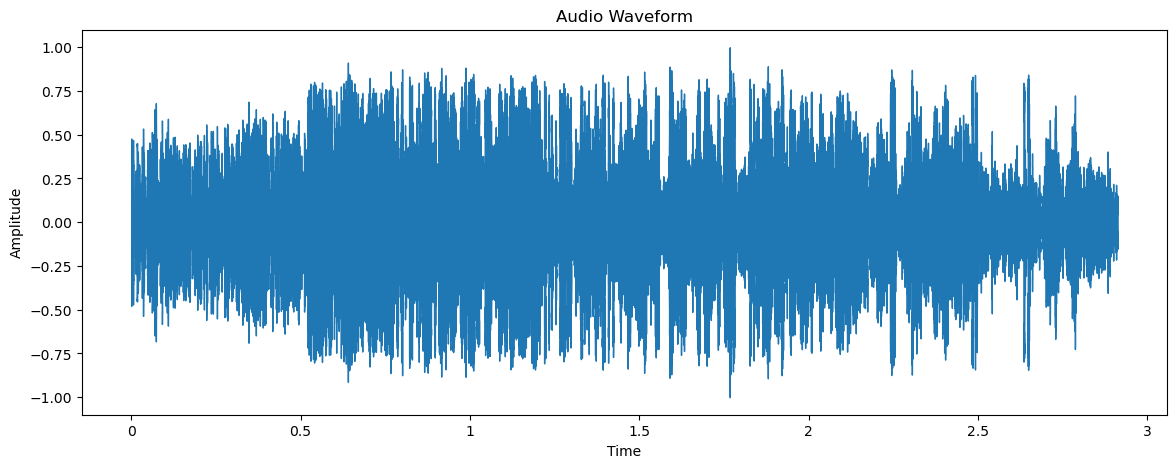

In [5]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(signal, sr=sr)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.show()

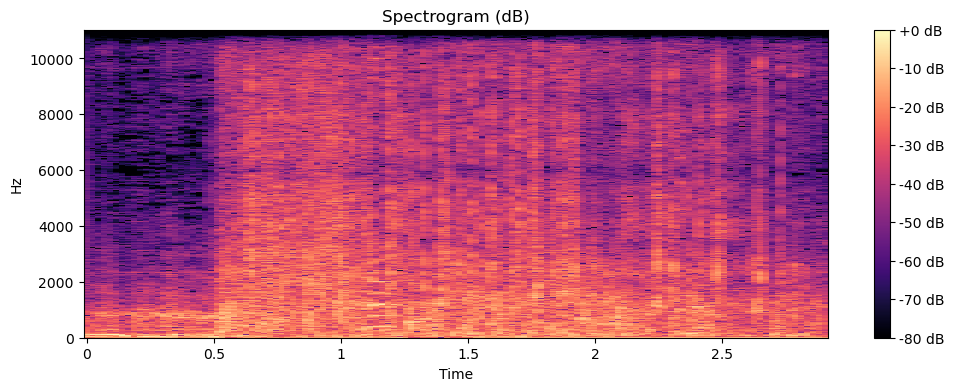

In [6]:
plt.figure(figsize=(12, 4))
spec = librosa.stft(signal)
spec_db = librosa.amplitude_to_db(np.abs(spec), ref=np.max)

librosa.display.specshow(spec_db, sr=sr, x_axis='time', y_axis='linear')
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram (dB)")
plt.show()

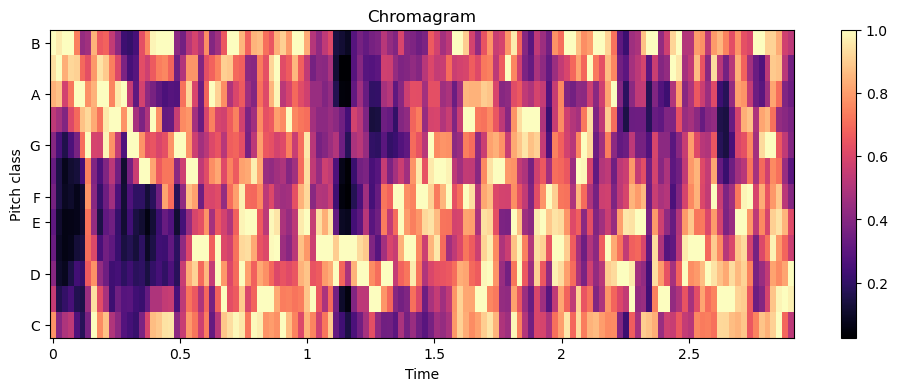

In [7]:
chromagram = librosa.feature.chroma_stft(y=signal, sr=sr)

plt.figure(figsize=(12, 4))
librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title("Chromagram")
plt.show()



In [11]:
 # Helper to summarize a feature matrix into fixed-size vector
def summarize(feat):
        if feat.ndim == 1:      # shape: (T,)
            return np.array([
                feat.mean(), feat.std(), feat.min(), feat.max()
            ])
        else:                   # shape: (F, T)
            return np.concatenate([
                feat.mean(axis=1),
                feat.std(axis=1),
                feat.min(axis=1),
                feat.max(axis=1)
            ])


In [29]:
#creating a list to store the features
features = []

# Time-domain features
zcr= librosa.feature.zero_crossing_rate(signal)
rms = librosa.feature.rms(y=signal)

In [30]:
# adding the summarized features to the list
features.append(summarize(zcr))
features.append(summarize(rms))

In [28]:
# Spectral domain features
stft = np.abs(librosa.stft(signal))
centroid = librosa.feature.spectral_centroid(S=stft)
bandwidth = librosa.feature.spectral_bandwidth(S=stft)
rolloff = librosa.feature.spectral_rolloff(S=stft)
flatness = librosa.feature.spectral_flatness(S=stft)
contrast = librosa.feature.spectral_contrast(S=stft)

In [17]:
features.append(summarize(centroid))
features.append(summarize(bandwidth))
features.append(summarize(rolloff))
features.append(summarize(flatness))
features.append(summarize(contrast))

In [32]:
# MFCCs - captures the texture of the sound
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
mfcc_delta = librosa.feature.delta(mfcc)
mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

In [19]:
features.append(summarize(mfcc_delta))
features.append(summarize(mfcc_delta2))

In [35]:
# Mel - captures the strength of the spectrogram in the human frequency range
mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)

features.append(summarize(mel))

In [36]:
# Chroma - captures the energy in 12 pitch classes
chroma = librosa.feature.chroma_stft(y=signal, sr=sr)

features.append(summarize(chroma))

In [37]:
# Tonnetz - captures the harmonic component od the sound
harmonic = librosa.effects.harmonic(signal)
tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)

features.append(summarize(harmonic))
features.append(summarize(tonnetz))

In [31]:
# converting all the features from the list into a single vector
vector = np.hstack(features)

In [24]:
print(vector)

[ 1.19512649e-01  5.31616992e-02  1.31835938e-02  2.29980469e-01
  2.66036570e-01  5.76480068e-02  8.20573717e-02  3.88333797e-01
  2.49548792e+03  8.03727327e+02  7.53961728e+02  3.73276887e+03
  2.55946827e+03  3.64349165e+02  1.50905290e+03  2.89959502e+03
  5.19206543e+03  1.95012179e+03  1.03359375e+03  7.24592285e+03
  6.82686642e-02  5.22637926e-02  2.98423925e-04  2.03475252e-01
  2.49548792e+03  8.03727327e+02  7.53961728e+02  3.73276887e+03
  2.55946827e+03  3.64349165e+02  1.50905290e+03  2.89959502e+03
  5.19206543e+03  1.95012179e+03  1.03359375e+03  7.24592285e+03
  6.82686642e-02  5.22637926e-02  2.98423925e-04  2.03475252e-01
  1.22439668e+01  1.01187140e+01  1.28935461e+01  1.43646429e+01
  1.48927059e+01  1.69035994e+01  4.39680969e+01  4.04065982e+00
  2.87146026e+00  3.29587445e+00  2.83161600e+00  2.21729541e+00
  3.00927337e+00  5.02640866e+00  4.87179320e+00  5.30135443e+00
  6.15326061e+00  9.61592634e+00  9.77065536e+00  6.82660984e+00
  1.56176298e+01  2.83018